# 03 — DEM Features

Derive terrain variables per hex cell from `dem_emerald.tif`.

All slope/aspect/curvature computed from the 30m DEM via GDAL, then
summarised per cell using rasterstats zonal statistics.

**Features produced per cell:**

| Feature | Description |
|---|---|
| `elev_mean` | Mean elevation (m) |
| `elev_min` / `elev_max` | Elevation range endpoints |
| `elev_std` | Elevation variability within cell |
| `slope_mean` | Mean slope (degrees) |
| `aspect_cos` / `aspect_sin` | Circular-encoded mean aspect |
| `relief` | elev_max − elev_min |
| `northness` | cos(aspect) — positive = north-facing |
| `eastness` | sin(aspect) — positive = east-facing |

**Outputs:**
- `data/raw/slope.tif`, `aspect.tif` — derived rasters
- `data/processed/dem_features.pkl` — per-cell feature DataFrame

In [1]:
from pathlib import Path
import subprocess
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import matplotlib.pyplot as plt

RAW  = Path('../data/raw')
PROC = Path('../data/processed')
IMG  = Path('../img')
PROC.mkdir(exist_ok=True)

DEM     = RAW / 'dem_emerald.tif'
SLOPE   = RAW / 'slope.tif'
ASPECT  = RAW / 'aspect.tif'

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Derive slope and aspect rasters via GDAL

In [2]:
if not SLOPE.exists():
    print('Computing slope...')
    subprocess.run(
        ['gdaldem', 'slope', str(DEM), str(SLOPE), '-compute_edges'],
        check=True, capture_output=True
    )
    print(f'  Saved {SLOPE}')
else:
    print('slope.tif cached')

if not ASPECT.exists():
    print('Computing aspect...')
    subprocess.run(
        ['gdaldem', 'aspect', str(DEM), str(ASPECT), '-compute_edges', '-zero_for_flat'],
        check=True, capture_output=True
    )
    print(f'  Saved {ASPECT}')
else:
    print('aspect.tif cached')

Computing slope...
  Saved ../data/raw/slope.tif
Computing aspect...
  Saved ../data/raw/aspect.tif


## 2. Zonal statistics per hex cell

In [3]:
hex_grid = gpd.read_file(RAW / 'hex_grid.gpkg')

# Reproject hex grid to match DEM CRS (should already match, but be safe)
with rasterio.open(DEM) as src:
    dem_crs = src.crs
hex_grid = hex_grid.to_crs(dem_crs)

print(f'Cells: {len(hex_grid):,}')
print(f'DEM CRS: {dem_crs}')

Cells: 8,923
DEM CRS: EPSG:32610


In [4]:
def zonal(raster_path, gdf, stats, prefix, nodata=-9999):
    """Run zonal_stats and return a DataFrame with prefixed column names."""
    print(f'  {Path(raster_path).name}: {stats} ...')
    results = zonal_stats(
        gdf, str(raster_path),
        stats=stats, nodata=nodata, all_touched=False
    )
    df = pd.DataFrame(results)
    df.columns = [f'{prefix}{c}' for c in df.columns]
    return df

print('Running zonal statistics...')
elev_df   = zonal(DEM,    hex_grid, ['mean','min','max','std'], 'elev_')
slope_df  = zonal(SLOPE,  hex_grid, ['mean'],                  'slope_')
aspect_df = zonal(ASPECT, hex_grid, ['mean'],                  'aspect_raw_')

print('Done')

Running zonal statistics...
  dem_emerald.tif: ['mean', 'min', 'max', 'std'] ...
  slope.tif: ['mean'] ...
  aspect.tif: ['mean'] ...
Done


In [5]:
# Assemble feature table
feats = pd.concat([
    hex_grid[['cell_id']].reset_index(drop=True),
    elev_df, slope_df, aspect_df,
], axis=1)

# Circular encoding of aspect (degrees → cos/sin)
# Handles the 0°/360° wraparound; 'northness' and 'eastness' are interpretable
aspect_rad = np.radians(feats['aspect_raw_mean'].fillna(0))
feats['aspect_cos'] = np.cos(aspect_rad)   # northness: +1 = N, -1 = S
feats['aspect_sin'] = np.sin(aspect_rad)   # eastness:  +1 = E, -1 = W
feats = feats.drop(columns=['aspect_raw_mean'])

# Relief = local elevation range within cell
feats['relief'] = feats['elev_max'] - feats['elev_min']

# Drop cells with no DEM data (ocean / outside)
n_before = len(feats)
feats = feats.dropna(subset=['elev_mean']).reset_index(drop=True)
print(f'Dropped {n_before - len(feats)} cells with no DEM coverage')
print(f'Remaining: {len(feats):,} cells')
print()
print(feats.describe().round(1))

Dropped 275 cells with no DEM coverage
Remaining: 8,648 cells

       elev_mean  elev_min  elev_max  elev_std  slope_mean  aspect_cos  \
count     8648.0    8648.0    8648.0    8648.0      8648.0      8648.0   
mean       681.3     499.9     881.9      85.8        17.5        -0.6   
std        500.9     447.4     556.5      45.5         7.6         0.6   
min         -0.3      -1.2       0.0       0.0         0.0        -1.0   
25%        288.8     126.9     485.7      59.3        14.7        -1.0   
50%        599.8     398.7     820.5      85.9        18.5        -0.9   
75%       1000.2     780.6    1245.3     114.4        22.3        -0.6   
max       2480.7    2304.2    2749.7     301.5        37.0         1.0   

       aspect_sin  relief  
count      8648.0  8648.0  
mean          0.0   382.0  
std           0.5   195.2  
min          -1.0     0.0  
25%          -0.4   269.8  
50%           0.0   386.0  
75%           0.4   503.8  
max           1.0  1203.2  


## 3. Quick maps

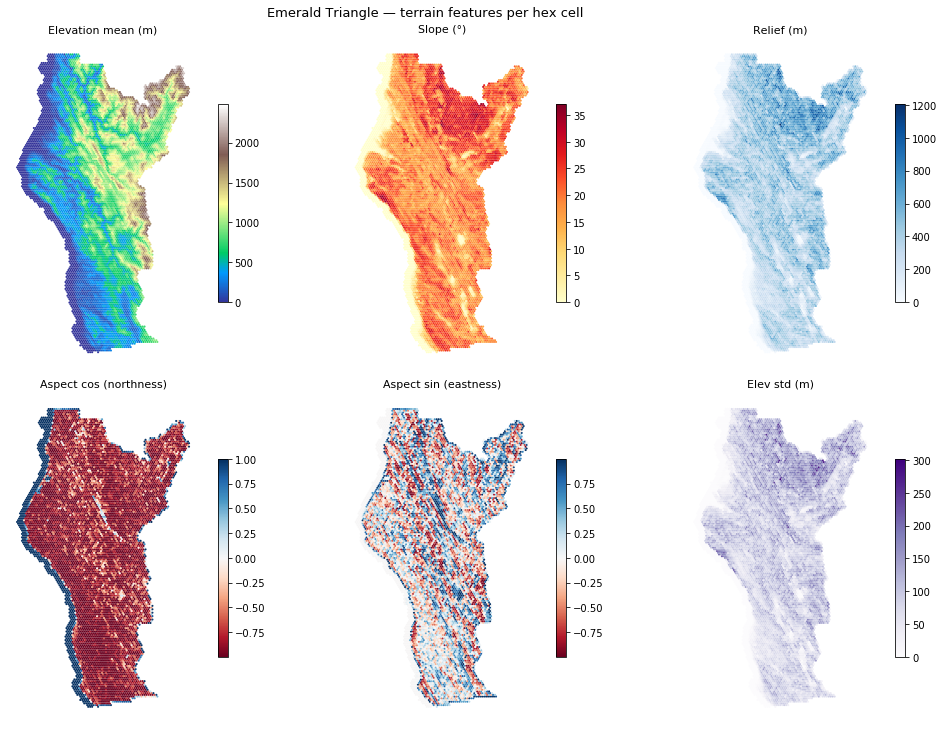

Saved img/03_dem_features.png


In [6]:
# Merge features back onto hex geometry for plotting
hex_feats = hex_grid.merge(feats, on='cell_id', how='inner')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
plot_cols = ['elev_mean', 'slope_mean', 'relief', 'aspect_cos', 'aspect_sin', 'elev_std']
titles    = ['Elevation mean (m)', 'Slope (°)', 'Relief (m)',
             'Aspect cos (northness)', 'Aspect sin (eastness)', 'Elev std (m)']
cmaps     = ['terrain', 'YlOrRd', 'Blues', 'RdBu', 'RdBu', 'Purples']

for ax, col, title, cmap in zip(axes.flat, plot_cols, titles, cmaps):
    hex_feats.plot(column=col, ax=ax, cmap=cmap, legend=True,
                   legend_kwds={'shrink': 0.6}, linewidth=0)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

plt.suptitle('Emerald Triangle — terrain features per hex cell', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../img/03_dem_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/03_dem_features.png')

## 4. Save

In [7]:
out = PROC / 'dem_features.pkl'
feats.to_pickle(out)
print(f'Saved {out}')
print(f'Shape: {feats.shape}')
print(f'Columns: {feats.columns.tolist()}')
print()
print('Next: 04_ndvi.ipynb — Sentinel-2 NDVI via Google Earth Engine')

Saved ../data/processed/dem_features.pkl
Shape: (8648, 9)
Columns: ['cell_id', 'elev_mean', 'elev_min', 'elev_max', 'elev_std', 'slope_mean', 'aspect_cos', 'aspect_sin', 'relief']

Next: 04_ndvi.ipynb — Sentinel-2 NDVI via Google Earth Engine
